In [1]:
import os
import cv2
import matplotlib.pyplot as plt

In [13]:
path_mm = "/home/a.samir/IMDL-HyFusion/inference_results_mm_columbia"
path_seg = "/home/a.samir/IMDL-HyFusion/inference_results_seg_columbia"
path_gt = "/scratch/dr/a.samir/IMDL/IMDL-HyFusion/data/Columbia/4cam_auth/edgemask"

In [14]:
def get_all_image_paths(root_dir, exts={'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}):
    image_paths = []
    for dirpath, _, filenames in os.walk(root_dir):
        for fname in filenames:
            if os.path.splitext(fname)[1].lower() in exts:
                image_paths.append(os.path.join(dirpath, fname))
    return image_paths

# Example usage:
image_paths_mm = get_all_image_paths(path_mm)
image_paths_seg = get_all_image_paths(path_seg)
mask_bin_paths_mm = [p for p in image_paths_mm if "mask_bin" in os.path.basename(p)]
original_paths_mm = [p for p in image_paths_mm if "original" in os.path.basename(p)]
mask_bin_paths_seg = [p for p in image_paths_seg if "mask_bin" in os.path.basename(p)]
gt_masks = get_all_image_paths(path_gt)
print(f"Found {len(image_paths_mm)} images in base_path_mm")
print(f"Found {len(image_paths_seg)} images in base_path_seg")
print(f"Found {len(mask_bin_paths_mm)} mask_bin images")
print(f"Found {len(original_paths_mm)} original images")
print(f"Found {len(mask_bin_paths_seg)} mask_bin images in segmentation results")
print(f"Found {len(gt_masks)} ground truth masks")

Found 549 images in base_path_mm
Found 549 images in base_path_seg
Found 183 mask_bin images
Found 183 original images
Found 183 mask_bin images in segmentation results
Found 366 ground truth masks


In [16]:
original_paths_mm = sorted(original_paths_mm)
original_paths_seg = sorted(original_paths_seg)
mask_bin_paths_mm = sorted(mask_bin_paths_mm)
mask_bin_paths_seg = sorted(mask_bin_paths_seg)
gt_masks = sorted(gt_masks)
gt_masks = [p for p in gt_masks if "edgemask_3" in os.path.basename(p)]
gt_masks = sorted(gt_masks)
# print(original_paths_mm[0], original_paths_seg[0])
# print(mask_bin_paths_mm[0], mask_bin_paths_seg[0])
# print(gt_masks[0])

183


/home/a.samir/IMDL-HyFusion/inference_results_mm_columbia/canong3_02_sub_01_original.png


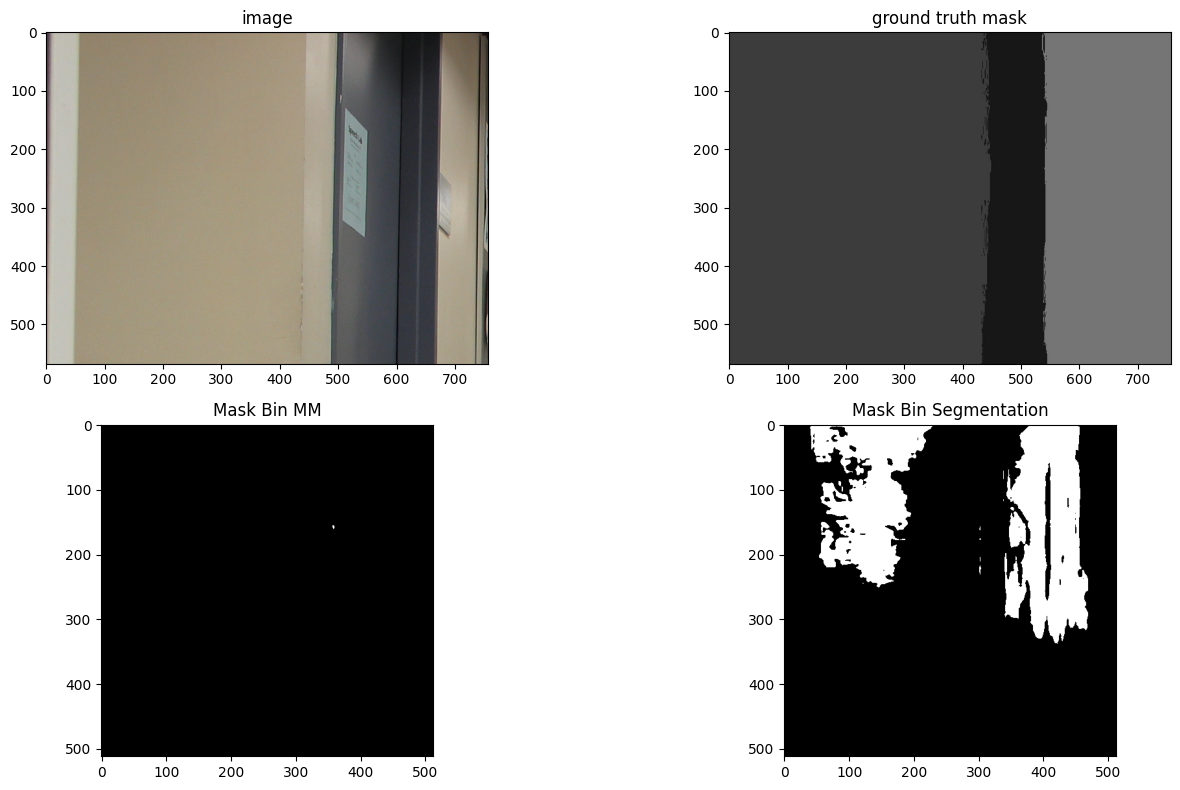

/home/a.samir/IMDL-HyFusion/inference_results_mm_columbia/canong3_02_sub_02_original.png


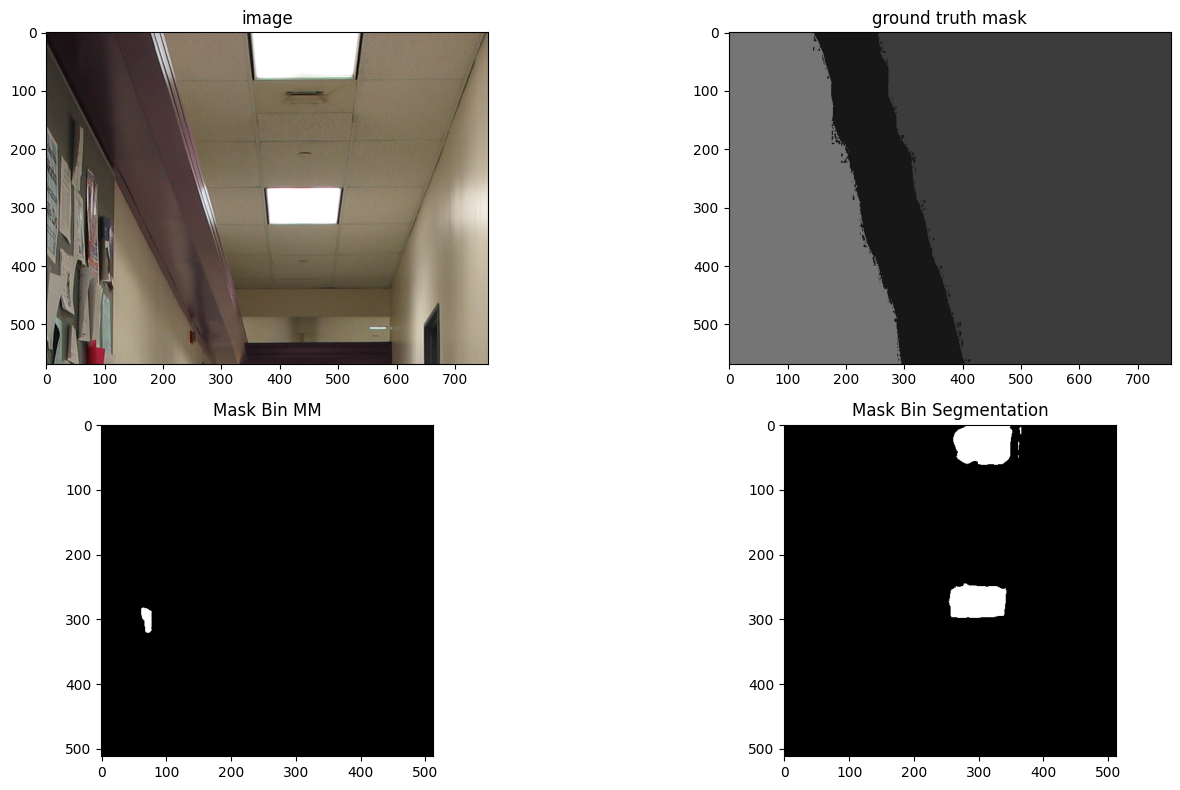

/home/a.samir/IMDL-HyFusion/inference_results_mm_columbia/canong3_02_sub_03_original.png


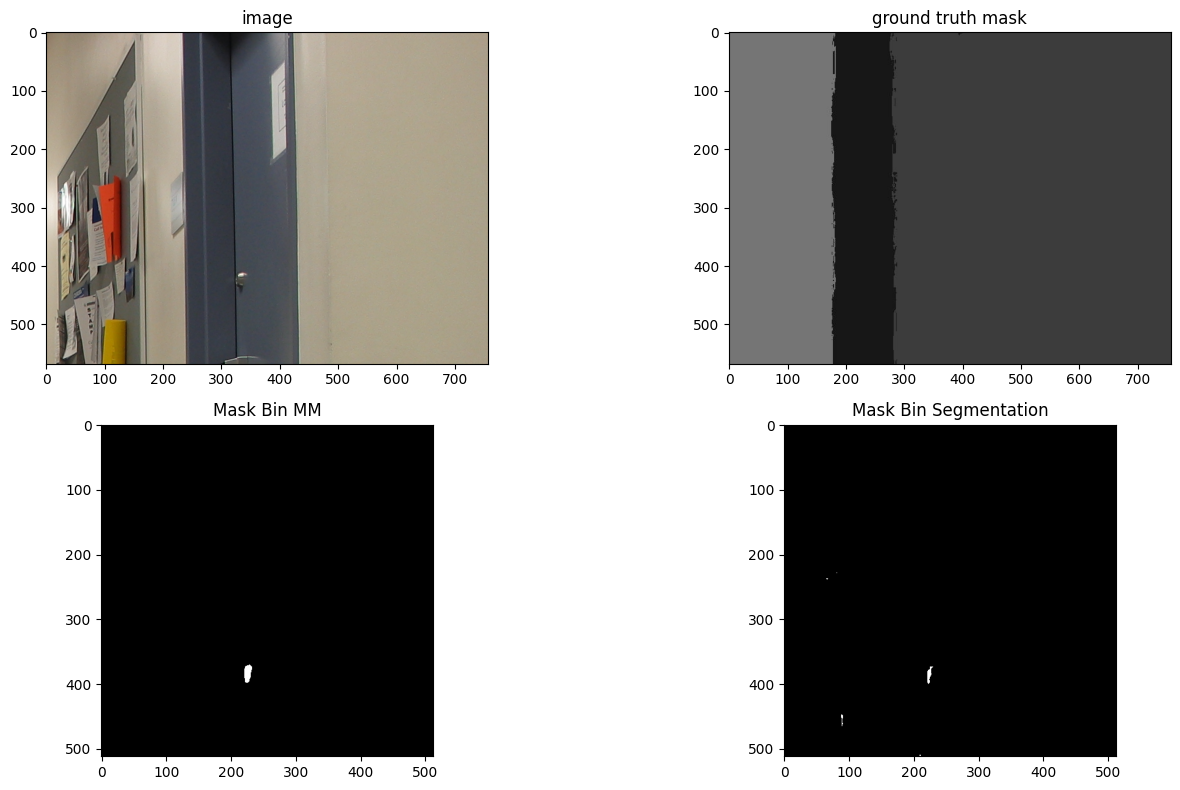

/home/a.samir/IMDL-HyFusion/inference_results_mm_columbia/canong3_02_sub_04_original.png


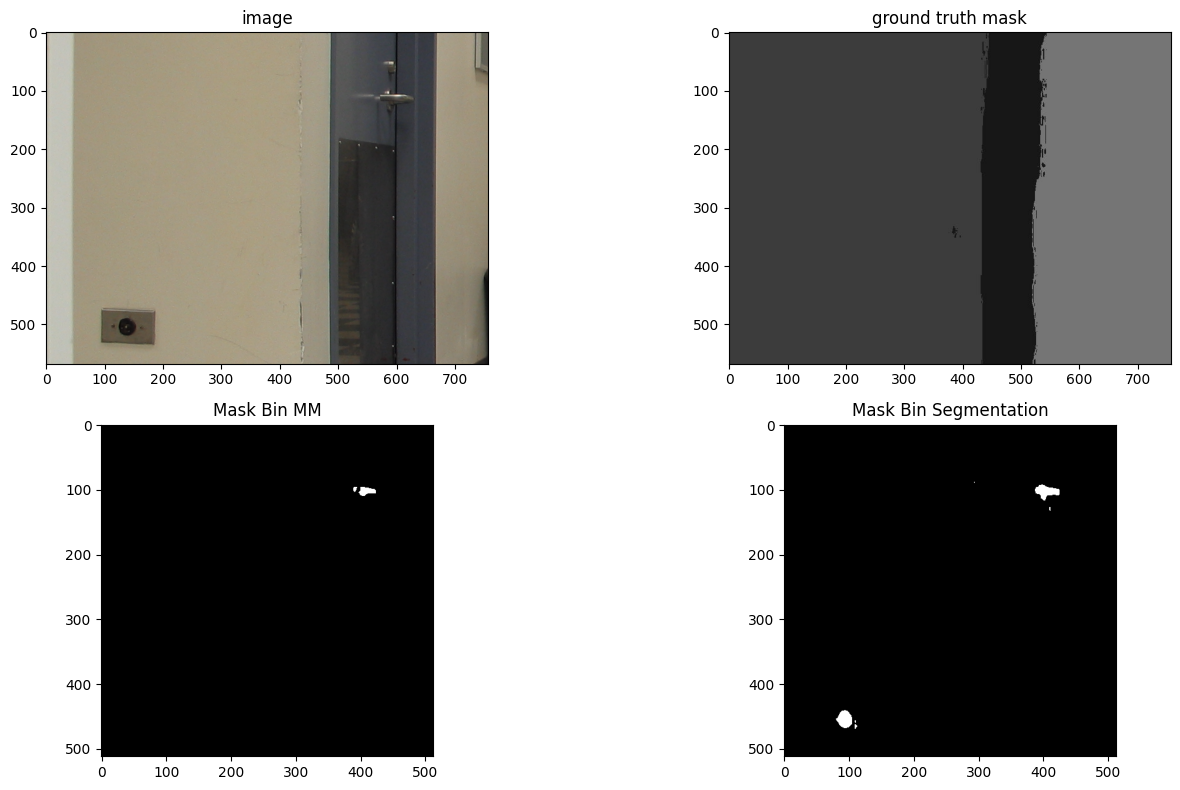

/home/a.samir/IMDL-HyFusion/inference_results_mm_columbia/canong3_02_sub_05_original.png


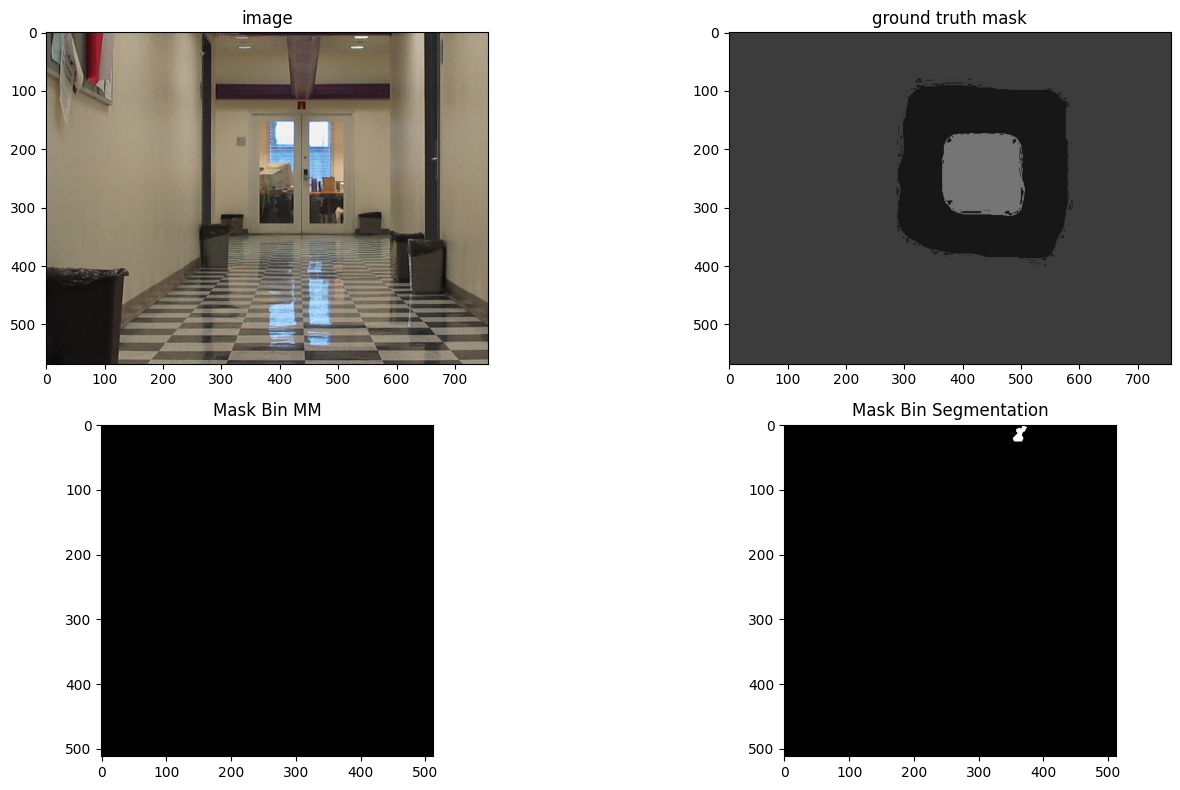

/home/a.samir/IMDL-HyFusion/inference_results_mm_columbia/canong3_02_sub_06_original.png


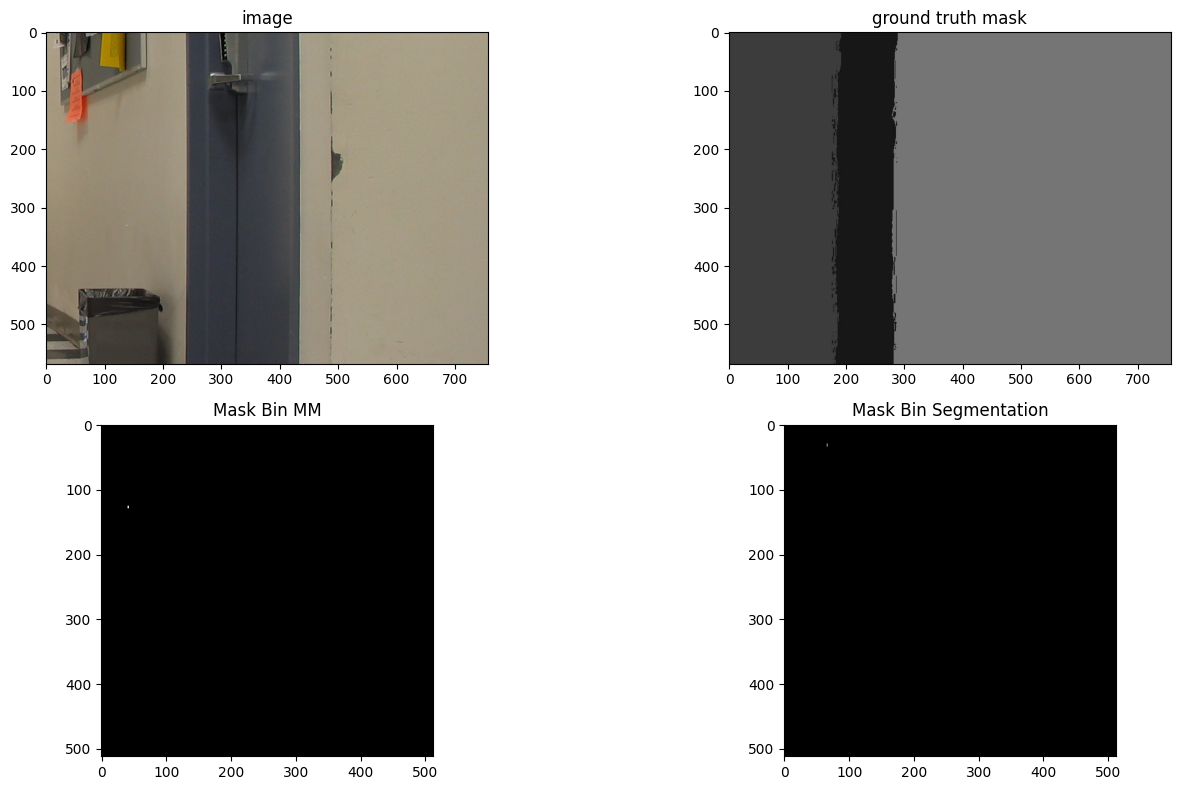

/home/a.samir/IMDL-HyFusion/inference_results_mm_columbia/canong3_02_sub_07_original.png


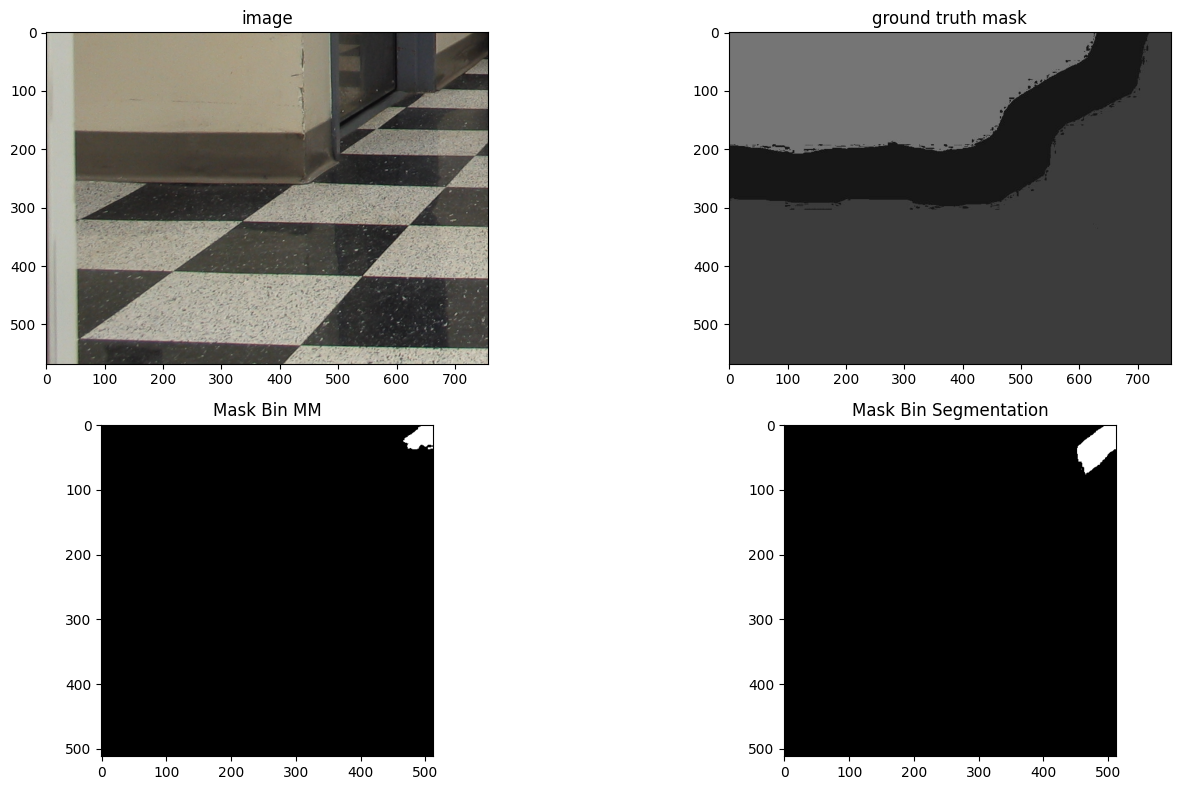

/home/a.samir/IMDL-HyFusion/inference_results_mm_columbia/canong3_02_sub_08_original.png


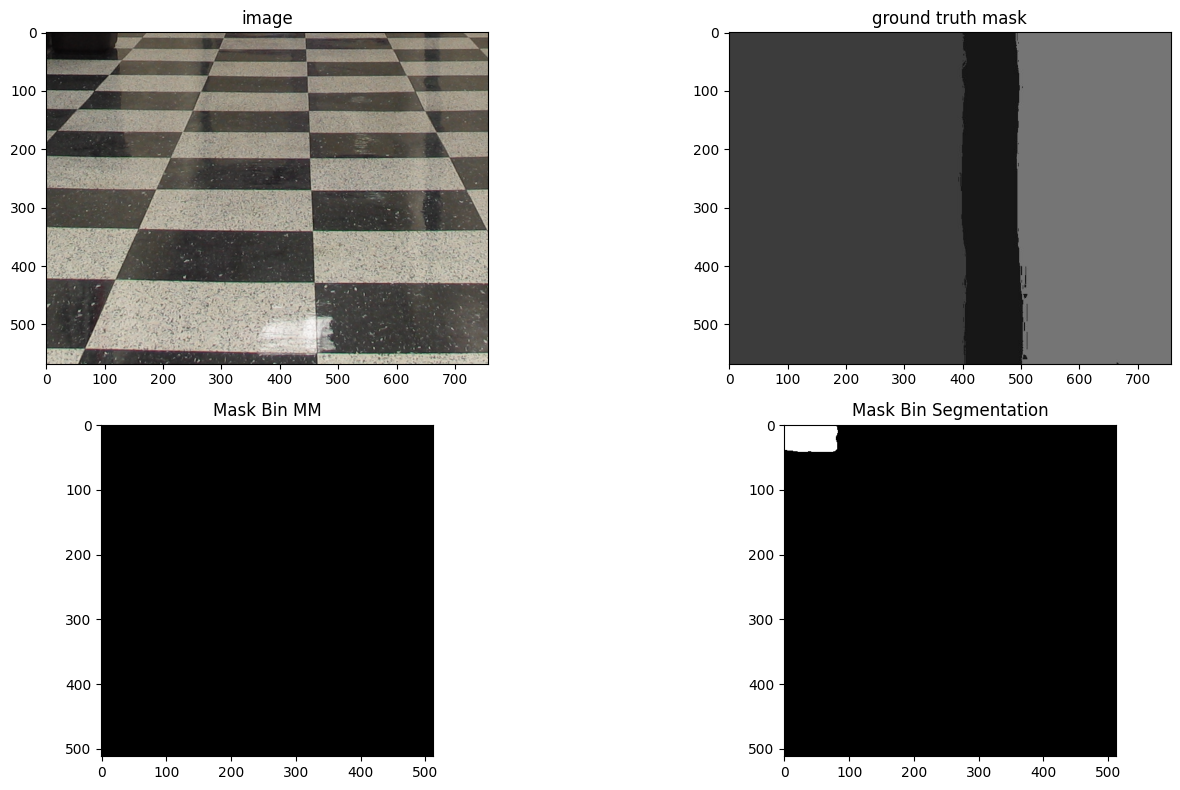

/home/a.samir/IMDL-HyFusion/inference_results_mm_columbia/canong3_02_sub_09_original.png


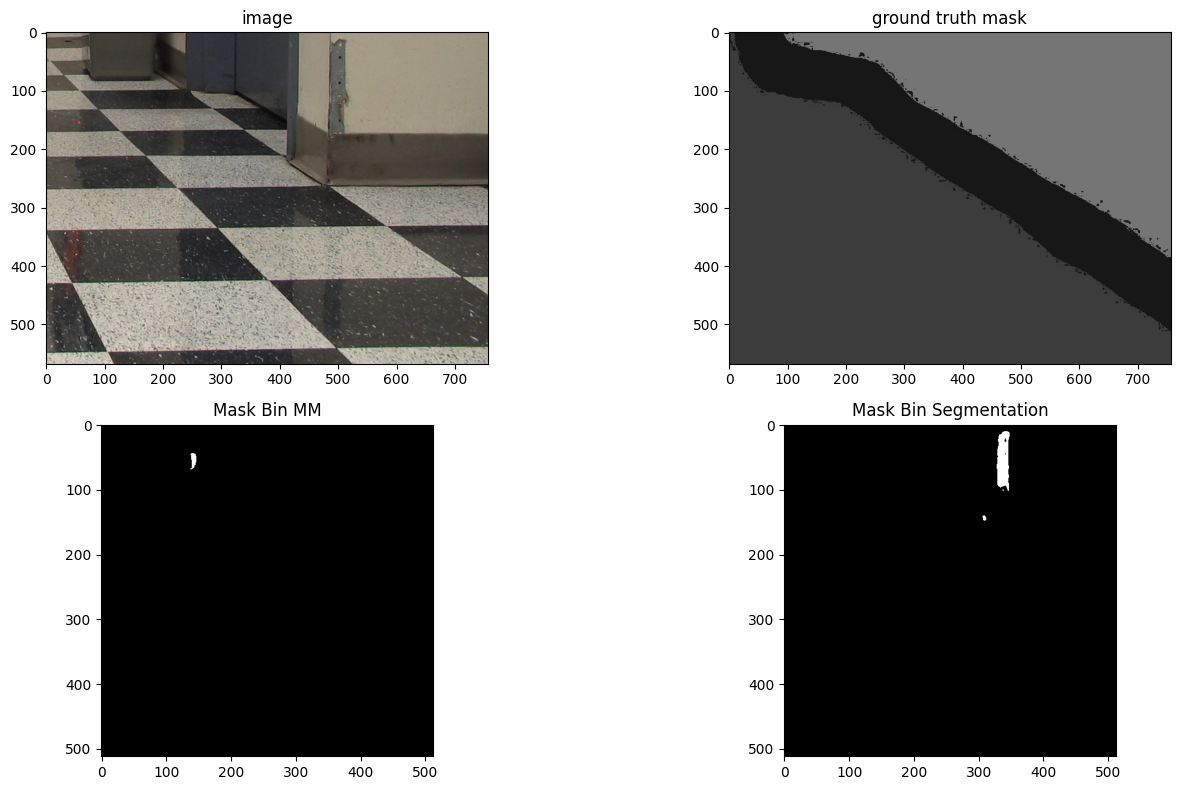

/home/a.samir/IMDL-HyFusion/inference_results_mm_columbia/canong3_05_sub_01_original.png


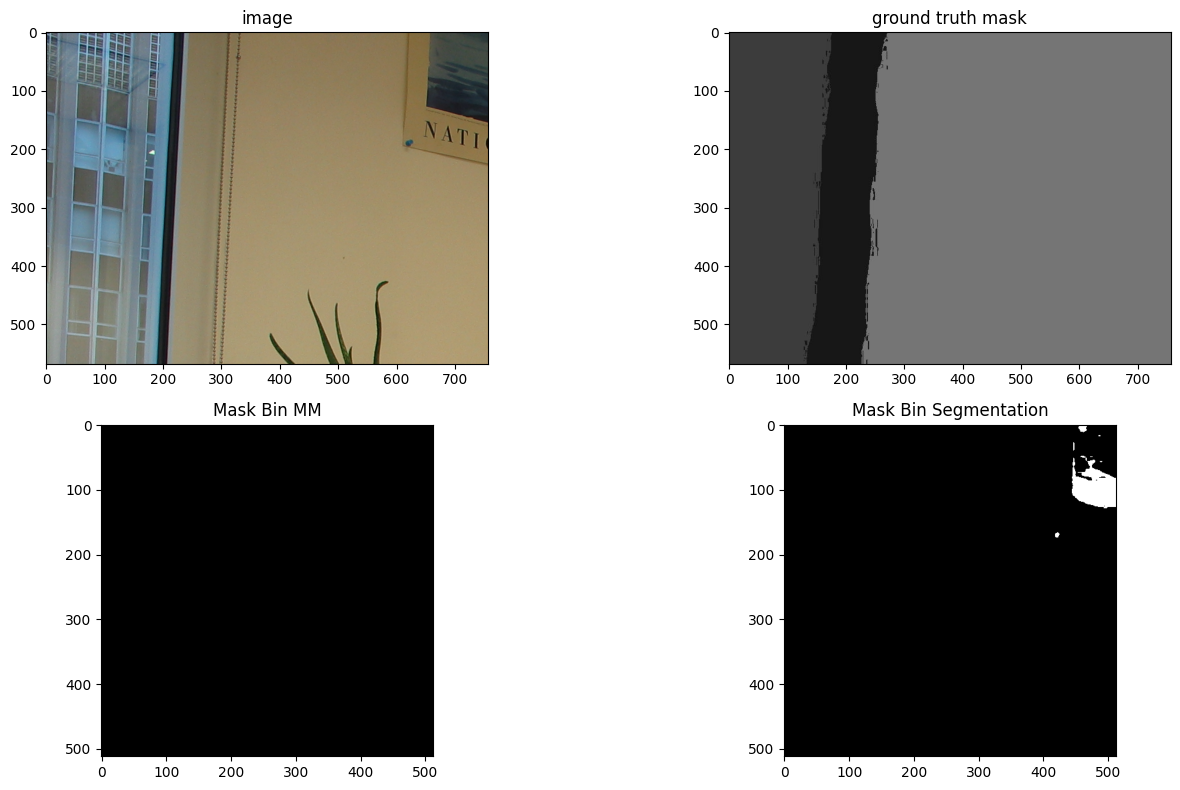

In [19]:
start = 0
step = 10
for i in range(start, start + step):
    print(original_paths_mm[i])
    mask_bin_mm = cv2.imread(mask_bin_paths_mm[i], cv2.IMREAD_GRAYSCALE)
    original_mm = cv2.imread(original_paths_mm[i])
    mask_bin_seg = cv2.imread(mask_bin_paths_seg[i], cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.imread(gt_masks[i], cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(15, 8))
    
    plt.subplot(221)
    plt.imshow(cv2.cvtColor(original_mm, cv2.COLOR_BGR2RGB))
    plt.title('image')
    
    plt.subplot(222)
    plt.imshow(cv2.cvtColor(gt_mask, cv2.COLOR_BGR2RGB))
    plt.title('ground truth mask')
    
    plt.subplot(223)
    plt.imshow(mask_bin_mm, cmap='gray')
    plt.title('Mask Bin MM')
    
    plt.subplot(224)
    plt.imshow(mask_bin_seg, cmap='gray')
    plt.title('Mask Bin Segmentation')
    
    plt.tight_layout()
    plt.show()


In [66]:
paths = ["/scratch/dr/a.samir/IMDL/IMDL-HyFusion/inference_results_mm_casiav1_cm/Sp_S_CNN_A_pla0052_pla0052_0005_original.png",
"/scratch/dr/a.samir/IMDL/IMDL-HyFusion/inference_results_mm_casiav1_cm/Sp_S_NND_A_art0058_art0058_0260_original.png",
"/scratch/dr/a.samir/IMDL/IMDL-HyFusion/inference_results_mm_casiav1_cm/Sp_S_CRN_A_pla0079_pla0079_0002_original.png",
"/scratch/dr/a.samir/IMDL/IMDL-HyFusion/inference_results_mm_casiav1_cm/Sp_S_NND_A_nat0054_nat0054_0189_original.png",
"/scratch/dr/a.samir/IMDL/IMDL-HyFusion/inference_results_mm_casiav1_cm/Sp_S_NNN_A_arc0022_arc0022_0015_original.png",
"/scratch/dr/a.samir/IMDL/IMDL-HyFusion/inference_results_mm_casiav1_cm/Sp_S_NNN_A_arc0039_arc0039_0017_original.png",
]

In [67]:
import cv2

def get_all_paths(path, gt_base_path):
    # Build paths
    mm_bin_mask_path = path.replace("original", "mask_bin")
    seg_bin_mask_path = mm_bin_mask_path.replace("mm", "seg")
    gt_path = gt_base_path + path.replace("original", "gt").split("/")[-1]

    # Load images
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    gt = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
    mm_bin_mask = cv2.imread(mm_bin_mask_path, cv2.IMREAD_GRAYSCALE)
    seg_bin_mask = cv2.imread(seg_bin_mask_path, cv2.IMREAD_GRAYSCALE)

    # Resize masks to match GT size
    if mm_bin_mask.shape[:2] != gt.shape[:2]:
        mm_bin_mask = cv2.resize(mm_bin_mask, (gt.shape[1], gt.shape[0]), interpolation=cv2.INTER_NEAREST)
    if seg_bin_mask.shape[:2] != gt.shape[:2]:
        seg_bin_mask = cv2.resize(seg_bin_mask, (gt.shape[1], gt.shape[0]), interpolation=cv2.INTER_NEAREST)

    return [img, gt, mm_bin_mask, seg_bin_mask]


In [98]:
import matplotlib.pyplot as plt
import numpy as np

def plot_image_table(image_list, start_row=0, end_row=None, save_path=None):
    """
    Plot a specific range of 4-image rows in a table format.
    
    Args:
        image_list: List of images where every 4 consecutive images form one row
                    [tampered1, gt1, mmfusion1, hyfusion1, tampered2, gt2, ...]
        start_row: Index of the starting row (0-based)
        end_row: Index of the ending row (exclusive). If None, goes to the last complete row
        save_path: Path to save the figure (if None, won't save)
    """
    headers = ["Tampered Image", "Ground Truth", "MMFusion Result", "Hy-Fusion Result"]
    
    total_rows = len(image_list) // 4

    # Default end_row to the last complete row if not provided
    if end_row is None:
        end_row = total_rows
    
    # Validate range
    if start_row >= total_rows or start_row < 0 or end_row <= start_row:
        print("Invalid row range.")
        return

    num_rows = end_row - start_row
    fig, axes = plt.subplots(num_rows, 4, figsize=(16, 4 * num_rows))

    if num_rows == 1:
        axes = axes.reshape(1, -1)

    for row in range(num_rows):
        for col in range(4):
            img_idx = (start_row + row) * 4 + col
            if img_idx < len(image_list):
                img = image_list[img_idx]
                axes[row, col].imshow(img, cmap='gray' if img.ndim == 2 else None)
                axes[row, col].axis('off')
                if row == 0:
                    axes[row, col].set_title(headers[col], fontsize=12, fontweight='bold', pad=10)
            else:
                axes[row, col].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9, hspace=0.1, wspace=0.05)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")

    return fig


In [99]:
images = []
for path in paths:
    image_from_paths = get_all_paths(path, gt_base_path)
    for image in image_from_paths:
        images.append(image)

Figure saved to: /home/a.samir/IMDL-HyFusion/figure2.png


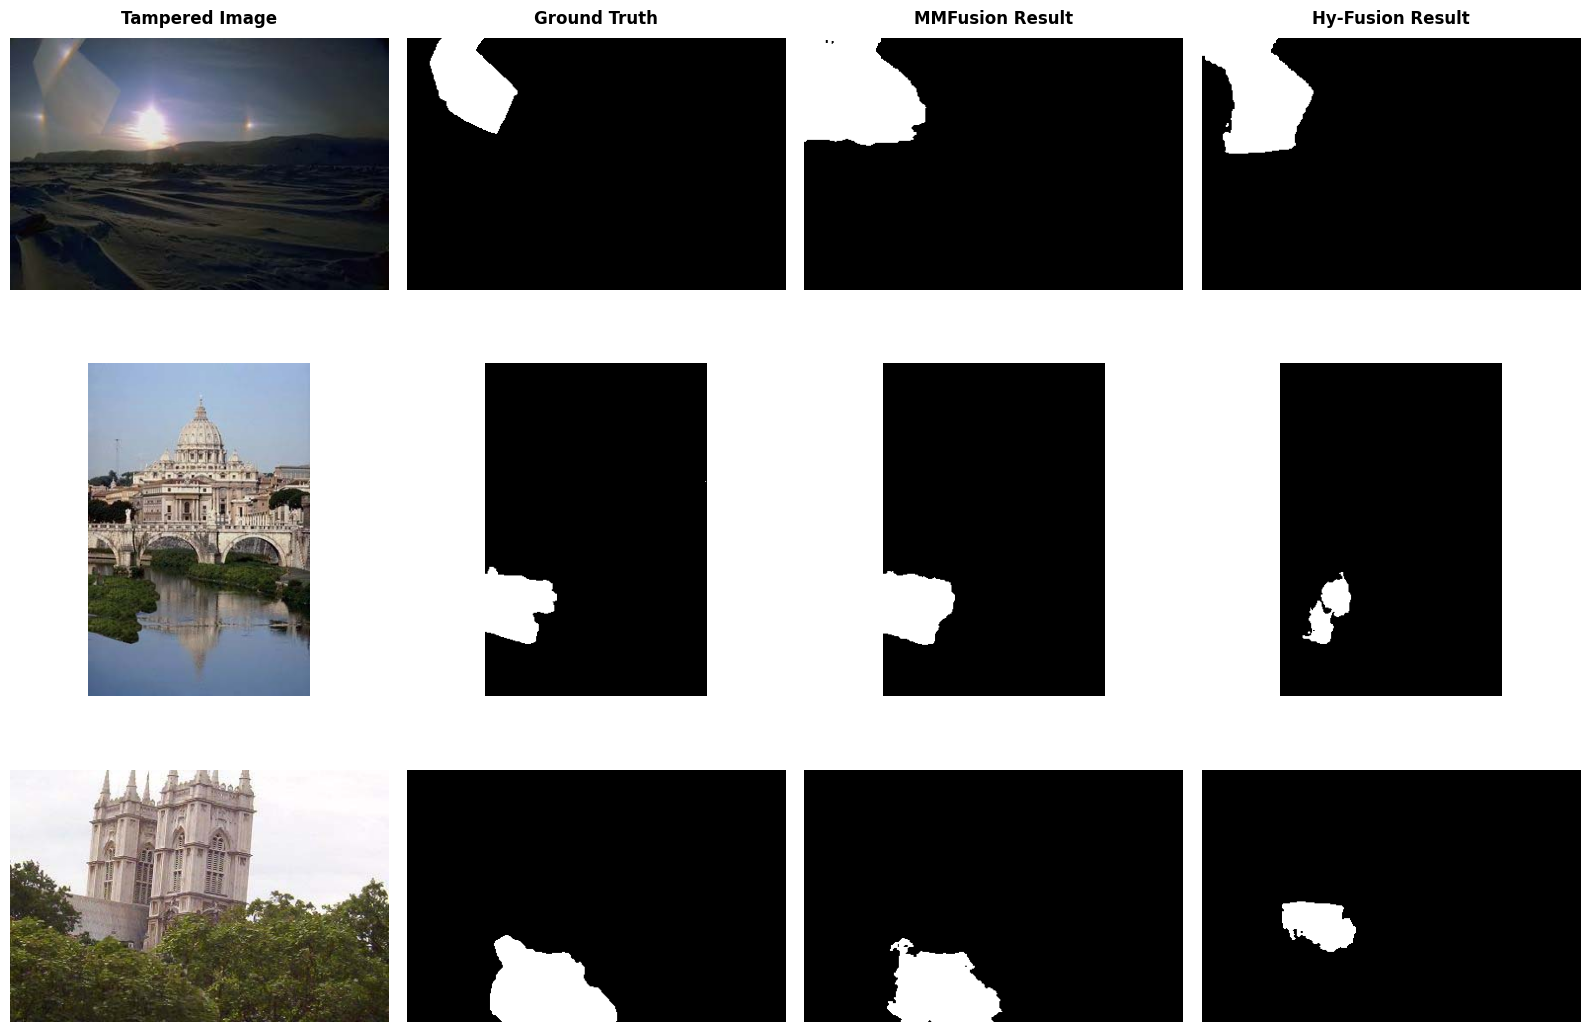

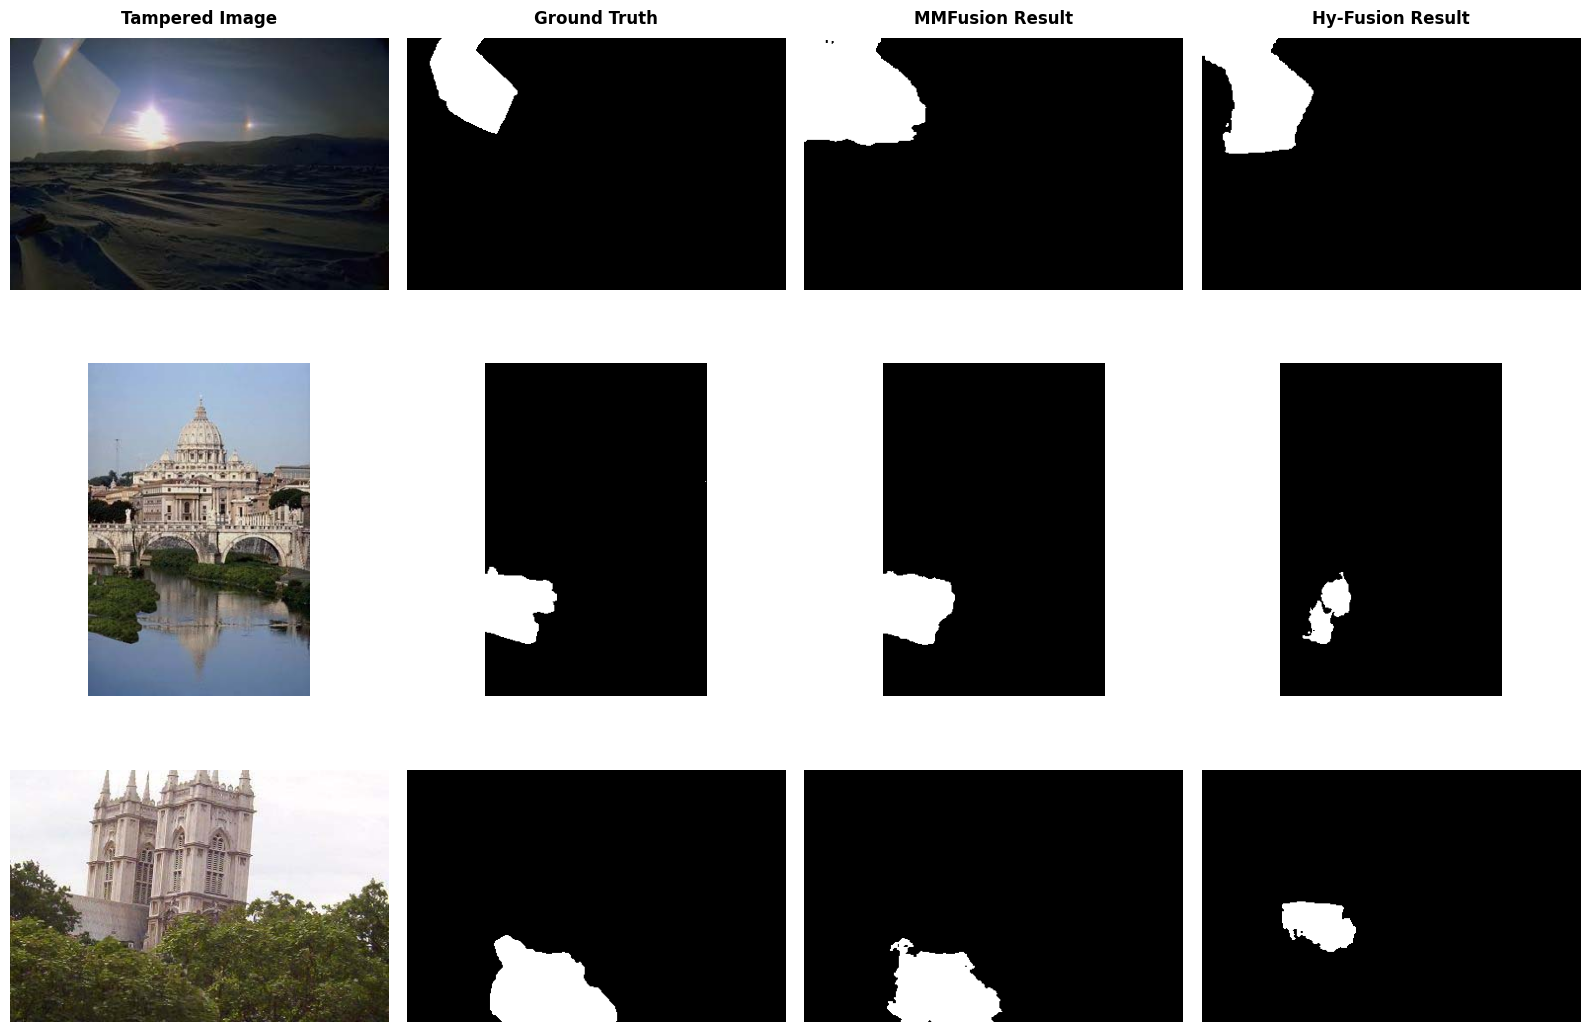

In [103]:
plot_image_table(images, start_row = 3, end_row=6,save_path = '/home/a.samir/IMDL-HyFusion/figure2.png')